# Reznar — Rarity prediction & anomaly detection

In [119]:
import db
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
with db.connect() as conn:
    df = pd.read_sql("SELECT * FROM items", conn)

# Pouch of False Coins is a known mis-extraction (no usable fields)
df = df[df["name"] != "Pouch of False Coins"].reset_index(drop=True)
print(df.shape)
df.head()

(79, 16)


/var/folders/1b/7qkztt_97sl2fl6cgw4fbj1h0000gn/T/ipykernel_39645/3098623631.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM items", conn)


,name,form,slot,rarity,req_attunement,offense_attack_damage_bonus,offense_effective_against,defense_ac_bonus,defense_condition_immunities,defense_resistances_against,defense_damage_resistances,environment_strong_in,limitations_charges,limitations_cursed,limitations_drawbacks,special_effects
0,Amulet of Fiendish Protection,amulet,neck,very_rare,True,0,[],4,[],[fiend],[],[],NaN,False,[],[grants advantage on saving throws against spe...
1,Amulet of Lycanthrope Protection,amulet,neck,rare,True,0,[],0,[lycanthropy],[],[],[],NaN,False,[],[Prevents lycanthropy curse from taking hold i...
2,Boots of Deception,boots,feet,rare,True,0,[],0,[],[],[],[],NaN,False,[],[Magically silence or amplify footsteps on any...
3,Boots of Stomping,boots,feet,uncommon,False,0,[],0,[],[],[],[],NaN,False,[],[Delivers a stomping blow to creatures at leas...
4,Caltrops of Wounding,wondrous,none,uncommon,False,0,[],0,[],[],[],[],NaN,False,[],[damage dealt can only be healed by magical me...


## EDA

Look for class imbalance, the size of the `varies` group (which doesn't sit on the ordinal scale), and whether obvious features trend with rarity.

rarity
uncommon      9
rare         28
very_rare    29
legendary     9
artifact      4


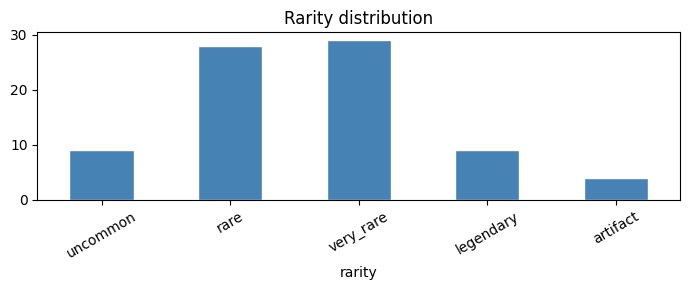

In [121]:
RARITY_ORDER = ["uncommon", "rare", "very_rare", "legendary", "artifact"]

counts = df["rarity"].value_counts().reindex(RARITY_ORDER).fillna(0).astype(int)
print(counts.to_string())

counts.plot(kind="bar", color="steelblue", edgecolor="white", figsize=(7, 3))
plt.title("Rarity distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

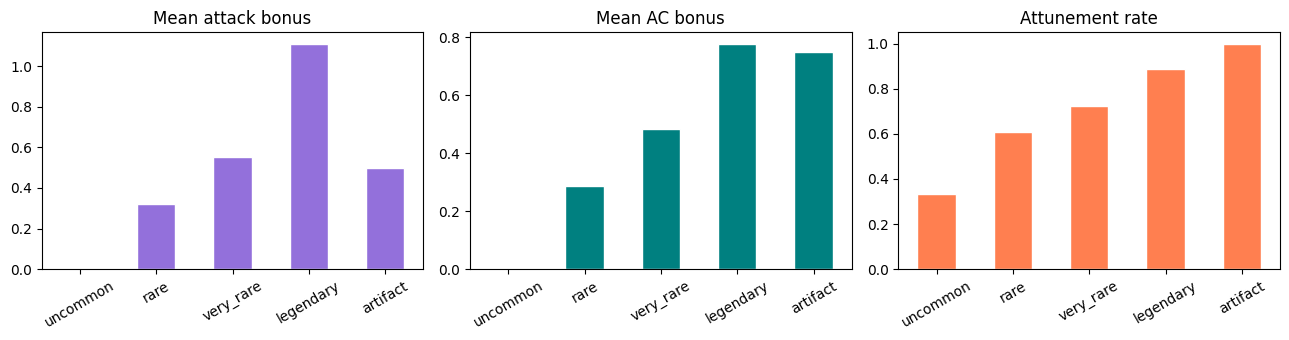

In [122]:
df_ord = df[df["rarity"].isin(RARITY_ORDER)].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
df_ord.groupby("rarity")["offense_attack_damage_bonus"].mean().reindex(RARITY_ORDER).plot(
    kind="bar", ax=axes[0], color="mediumpurple", edgecolor="white"
)
df_ord.groupby("rarity")["defense_ac_bonus"].mean().reindex(RARITY_ORDER).plot(
    kind="bar", ax=axes[1], color="teal", edgecolor="white"
)
df_ord.groupby("rarity")["req_attunement"].mean().reindex(RARITY_ORDER).plot(
    kind="bar", ax=axes[2], color="coral", edgecolor="white"
)
for ax, title in zip(axes, ["Mean attack bonus", "Mean AC bonus", "Attunement rate"]):
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Feature engineering

Convert array columns to cardinality counts, build the ordinal target, inspect feature-vs-target and feature-vs-feature correlation, then drop one of each pair with `|r| > 0.85`.

In [123]:
LIST_COLS = [
    "offense_effective_against",
    "defense_condition_immunities",
    "defense_resistances_against",
    "defense_damage_resistances",
    "environment_strong_in",
    "limitations_drawbacks",
    "special_effects",
]

# Filter to ordinal rarities — 'varies' is set aside for the writeup, not modeled
df_model = df[df["rarity"].isin(RARITY_ORDER)].reset_index(drop=True)

features = pd.DataFrame(index=df_model.index)
features["attack_bonus"] = df_model["offense_attack_damage_bonus"].fillna(0).astype(int)
features["ac_bonus"] = df_model["defense_ac_bonus"].fillna(0).astype(int)
features["charges"] = df_model["limitations_charges"].fillna(0).astype(int)
features["req_attunement"] = df_model["req_attunement"].astype(int)
features["cursed"] = df_model["limitations_cursed"].astype(int)

for col in LIST_COLS:
    features[f"n_{col.split('_', 1)[1]}"] = df_model[col].apply(
        lambda x: len(x) if x is not None else 0
    )


features["rarity_ord"] = df_model["rarity"].map({r: i for i, r in enumerate(RARITY_ORDER)})

print(features.shape)
features.head()

(79, 13)


,attack_bonus,ac_bonus,charges,req_attunement,cursed,n_effective_against,n_condition_immunities,n_resistances_against,n_damage_resistances,n_strong_in,n_drawbacks,n_effects,rarity_ord
0,0,4,0,1,0,0,0,1,0,0,0,1,2
1,0,0,0,1,0,0,1,0,0,0,0,1,1
2,0,0,0,1,0,0,0,0,0,0,0,2,1
3,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0


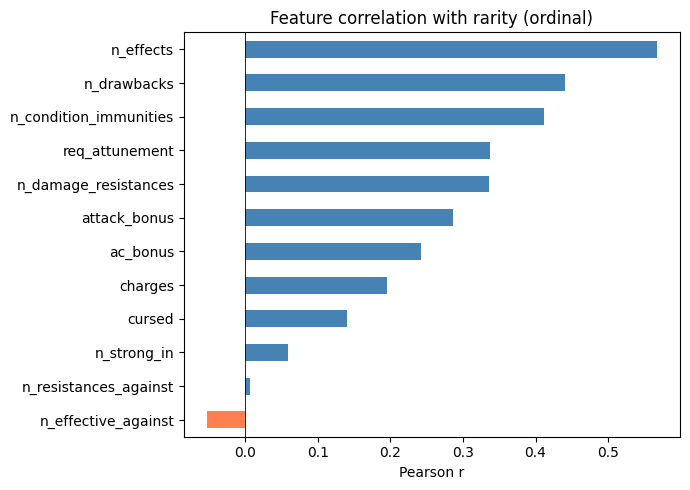

In [124]:
target_corr = features.corr(numeric_only=True)["rarity_ord"].drop("rarity_ord").sort_values()

plt.figure(figsize=(7, 5))
target_corr.plot(kind="barh", color=["coral" if v < 0 else "steelblue" for v in target_corr])
plt.axvline(0, color="black", linewidth=0.6)
plt.title("Feature correlation with rarity (ordinal)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

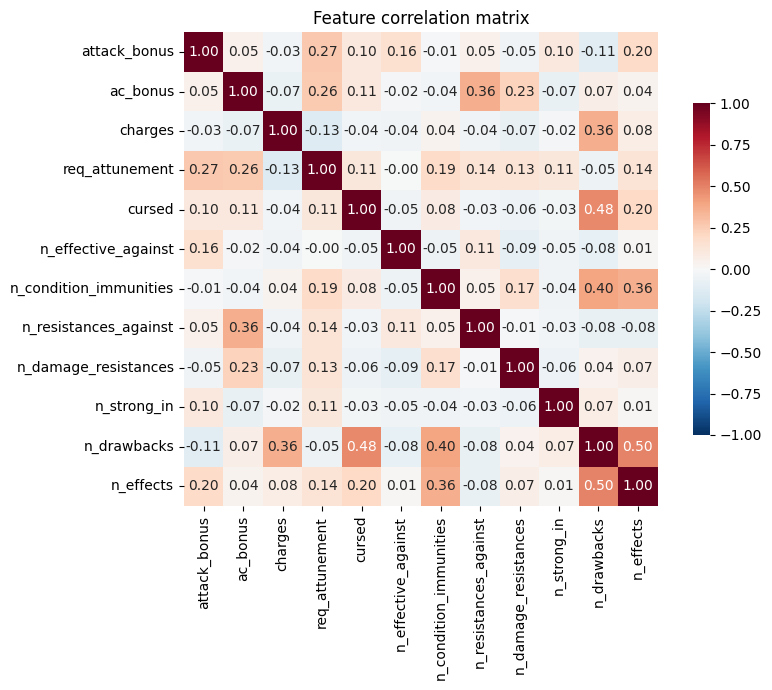

In [125]:
X = features.drop(columns="rarity_ord")
corr = X.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7},
)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [126]:
THRESHOLD = 0.80

upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
pairs = (
    upper.stack()
    .pipe(lambda s: s[s.abs() > THRESHOLD])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(f"Pairs with |r| > {THRESHOLD}:")
print(pairs.to_string() if len(pairs) else "  (none)")

# From each collinear pair, drop the feature with weaker correlation to the target
to_drop: set[str] = set()
for (a, b), _ in pairs.items():
    if a in to_drop or b in to_drop:
        continue
    drop = a if abs(target_corr[a]) < abs(target_corr[b]) else b
    to_drop.add(drop)

print(f"\nDropping: {sorted(to_drop)}")
X_pearson = X.drop(columns=list(to_drop))
print(f"Surviving features ({X_pearson.shape[1]}): {list(X_pearson.columns)}")

Pairs with |r| > 0.8:
  (none)

Dropping: []
Surviving features (12): ['attack_bonus', 'ac_bonus', 'charges', 'req_attunement', 'cursed', 'n_effective_against', 'n_condition_immunities', 'n_resistances_against', 'n_damage_resistances', 'n_strong_in', 'n_drawbacks', 'n_effects']


In [127]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X: pd.DataFrame) -> pd.Series:
    Xc = pd.concat([pd.Series(1.0, index=X.index, name="const"), X], axis=1)
    return pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
        index=X.columns,
    ).sort_values(ascending=False)


X_final = X_pearson.copy()
dropped: list[str] = []
while X_final.shape[1] >= 2:
    vif = compute_vif(X_final)
    worst, worst_v = vif.index[0], vif.iloc[0]
    if not np.isfinite(worst_v) or worst_v > 5.0:
        dropped.append(f"{worst} (VIF={worst_v:.1f})")
        X_final = X_final.drop(columns=worst)
    else:
        break

print(f"Dropped {len(dropped)} feature(s): {dropped}")
print(f"\nFinal VIF ({X_final.shape[1]} features):")
print(compute_vif(X_final).round(2).to_string())

Dropped 0 feature(s): []

Final VIF (12 features):
n_drawbacks               2.84
cursed                    1.61
n_effects                 1.60
n_condition_immunities    1.47
ac_bonus                  1.39
charges                   1.34
req_attunement            1.32
attack_bonus              1.28
n_resistances_against     1.23
n_damage_resistances      1.14
n_strong_in               1.10
n_effective_against       1.06


## Model inputs

Materialize the final `X`, `y`, `names` arrays. `varies` is already excluded by the `RARITY_ORDER` filter above; report how many were dropped for the writeup.

In [128]:
X = X_final.to_numpy(dtype=float)
y = features["rarity_ord"].to_numpy(dtype=int)
names = df_model["name"].to_numpy()

n_varies = (df["rarity"] == "varies").sum()
print(f"X shape: {X.shape}")
print("class counts:", {RARITY_ORDER[k]: int(v) for k, v in pd.Series(y).value_counts().sort_index().items()})

X shape: (79, 12)
class counts: {'uncommon': 9, 'rare': 28, 'very_rare': 29, 'legendary': 9, 'artifact': 4}


## Testing approaches

Two facts about the data shape everything below:

1. **Rarity is ordered** — `uncommon < rare < very_rare < legendary < artifact`. Predicting `legendary` when the truth is `artifact` is a small miss; predicting `uncommon` is a big one. A good model should know the difference.
2. **The labels are noisy** — Reznar suspects some items sit in the wrong tier. So when a model disagrees with a label, we can't tell upfront whether the *model* is wrong or the *label* is. That tension is exactly what we want to surface later.

There are three natural ways to frame the problem, and we try each one:

- **Unordered classes** — treat the five tiers as five unrelated buckets (Random Forest classifier).
- **Ordinal-native** — a model built for ranked categories (ordinal logistic regression).
- **Regression** — predict rarity as a number on a 0–4 scale, which keeps the sense of *distance* between tiers.

The plan: build a candidate for each framing, **score them all the exact same way against a dumb baseline**, and keep only the models that are both accurate *and* non-redundant (i.e. don't make the same mistakes). Those survivors feed the anomaly ranking at the end.

> We deliberately stay with simple models, not deep learning — with only 79 items a neural net would memorize the noise and overfit. Start simple, prove signal, add complexity only if needed.

### Framing 1 — ordinal-native: does its core assumption hold?

The textbook model for ranked categories is **ordinal logistic regression (OLR)**. It rests on one strong assumption — **proportional odds**: every feature must push an item up the rarity ladder by the *same amount at every rung*. So `attack_bonus` would have to matter just as much for the `uncommon → rare` step as for the `legendary → artifact` step. (This is about the *slopes* being shared across rungs — not about the tiers being equally spaced; the rung thresholds themselves are learned freely.)

To check it, we fit a separate yes/no model at each rung (`is it ≥ rare?`, `is it ≥ very_rare?`, …) and compare each feature's slope across the rungs. If the bars line up, the assumption holds; if a feature's weight swings wildly or flips sign, it's violated.

**The catch:** the check hints the slopes aren't parallel — but with only 79 items, heavy class imbalance, and labels we already suspect are noisy, we can't separate a *genuine* violation from the *labels themselves being wrong*. So this is a **soft flag, not a verdict.** We won't crown the ordinal model on it, and we won't disqualify it either — we park the ordinal approach, explore the other two framings, and give it a fair second look later.

                        ≥ rare  ≥ very_rare  ≥ legendary  ≥ artifact  spread  sign_flip
attack_bonus              1.03         0.54         0.54       -0.10    1.13       True
n_damage_resistances      0.57         0.50         1.12        0.12    1.00      False
n_effects                 0.45         0.87         1.35        0.93    0.90      False
ac_bonus                  0.84         0.60         0.08        0.23    0.76      False
charges                   0.20         0.42         0.68       -0.03    0.71       True
n_strong_in               0.14         0.43        -0.27       -0.05    0.70       True
n_drawbacks               0.74         0.34         0.30        1.00    0.70      False
req_attunement            0.43         0.26         0.94        0.37    0.68      False
cursed                    0.02        -0.50        -0.04        0.16    0.65       True
n_resistances_against     0.20        -0.08        -0.35       -0.04    0.55       True
n_effective_against      -0.14  

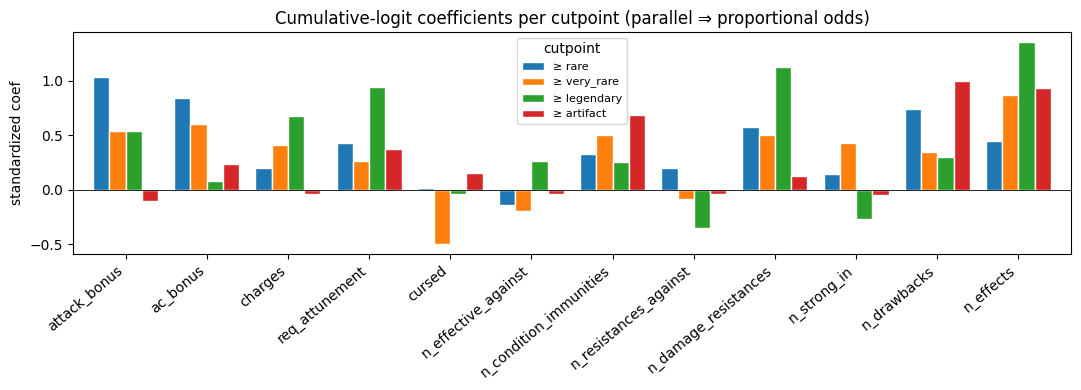

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X)

# Fit a binary logit at each cumulative cutpoint y >= k
coefs = {}
for k in range(1, len(RARITY_ORDER)):
    y_bin = (y >= k).astype(int)
    lr = LogisticRegression(C=1.0, max_iter=2000).fit(X_std, y_bin)
    coefs[f"≥ {RARITY_ORDER[k]}"] = lr.coef_[0]

coef_df = pd.DataFrame(coefs, index=X_final.columns)
spread = (coef_df.max(axis=1) - coef_df.min(axis=1)).rename("spread")
sign_flip = (coef_df.apply(np.sign).nunique(axis=1) > 1).rename("sign_flip")
summary = pd.concat([coef_df.round(2), spread.round(2), sign_flip], axis=1)
print(summary.sort_values("spread", ascending=False).to_string())

ax = coef_df.plot(kind="bar", figsize=(11, 4), edgecolor="white", width=0.8)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Cumulative-logit coefficients per cutpoint (parallel ⇒ proportional odds)")
ax.set_ylabel("standardized coef")
plt.xticks(rotation=40, ha="right")
plt.legend(title="cutpoint", fontsize=8)
plt.tight_layout()
plt.show()

### Framing 2 — unordered classes: Random Forest classifier

Since the assumption check was inconclusive, we don't bet on the ordinal model yet — we explore the other framings first and revisit it later. Swing to the opposite extreme: a **Random Forest classifier** that treats the five tiers as five *unrelated* labels. It makes no assumptions about ordering or spacing, handles non-linear patterns, and tolerates label noise well.

The trade-off is that it's blind to the ordering — confusing `uncommon` with `artifact` counts the same as confusing it with `rare`. The confusion matrix below makes that blindness visible: ideally the mass hugs the diagonal. (We hold off on scoring it here — every model gets scored together, the same way, in the final comparison.)

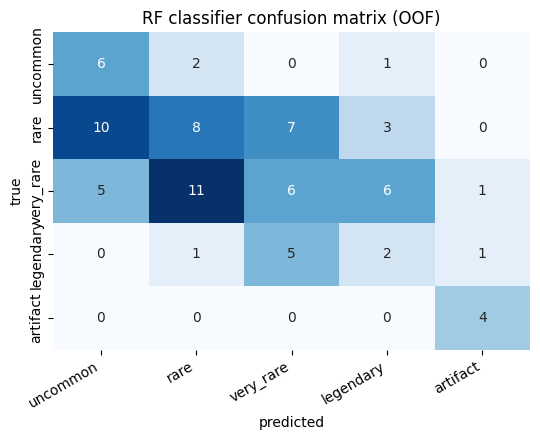

In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, confusion_matrix, mean_absolute_error
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)
rf_clf = RandomForestClassifier(
    n_estimators=500, max_depth=4, min_samples_leaf=5,
    class_weight="balanced", random_state=0, n_jobs=-1,
)
y_pred_clf = cross_val_predict(rf_clf, X, y, cv=cv)

# Visualize where the classifier lands — off-diagonal mass = ordering it can't see (full
# scoring happens in the final comparison, so no metric prints here).
cm = confusion_matrix(y, y_pred_clf, labels=range(len(RARITY_ORDER)))
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=RARITY_ORDER, yticklabels=RARITY_ORDER, cbar=False,
)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("RF classifier confusion matrix (OOF)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Framing 3 — regression: RF + Ridge

Neither extreme settles it: the ordinal model's assumption check was inconclusive, and the classifier is blind to ordering. **Regression** offers a third angle — predict rarity as a number on the 0–4 scale. This keeps the *distance* of errors (off-by-1 ≠ off-by-3) and gives a continuous score we can rank items by, which is exactly what the anomaly hunt needs. (The trade-off it accepts: encoding the tiers as 0–4 *does* assume they're evenly spaced — the very thing OLR avoids. We tolerate that for the ranking payoff and let the final comparison check whether it costs us.)

Because the labels are noisy, we don't trust one model. We run **two models with opposite styles**:

- **Random Forest** — flexible, non-linear, robust.
- **Ridge** — smooth, linear, steady.

When two such different models *agree* that an item looks mislabeled, that's far more convincing than either alone. One design choice worth flagging: both are trained to minimize **mean absolute error (MAE)**, not the usual squared error (MSE). MSE *squares* mistakes, so a single noisy label can dominate training — MAE treats every tier of error proportionally, which is safer when we expect the labels themselves to be wrong.

The cell below builds `oof_predict`, the shared out-of-fold harness every model runs through (so comparisons are apples-to-apples), and reports each model's prediction range.

In [131]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline


def oof_predict(estimator_factory, X, y, weight_key="sample_weight",
                score=lambda est, Xte: est.predict(Xte),
                n_splits=4, n_repeats=5, seed=0):
    """OOF continuous scores, averaged across repeats. Returns (mean, per-repeat matrix).
    `score(est, X_te)` maps a fitted model to a per-row score, so the same loop serves
    regressors (raw predict, the default) and classifiers (expected tier)."""
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    preds = np.zeros((n_repeats, len(y)))
    for fold_i, (tr, te) in enumerate(cv.split(X, y)):
        rep = fold_i // n_splits
        # handle class imbalance by weighting
        cls_counts = np.bincount(y[tr])
        w = 1.0 / cls_counts[y[tr]]
        est = estimator_factory()
        est.fit(X[tr], y[tr], **{weight_key: w})
        preds[rep, te] = score(est, X[te])  # te held out this fold → OOF
    return preds.mean(axis=0), preds


rf_factory = lambda: RandomForestRegressor(
    min_samples_leaf=5, random_state=0, n_jobs=-1, criterion="absolute_error", 
)
ridge_factory = lambda: Pipeline([("sc", StandardScaler()), ("ridge", Ridge(alpha=0.5))])

y_pred_rf,    preds_rf_all    = oof_predict(rf_factory,    X, y)
y_pred_ridge, preds_ridge_all = oof_predict(ridge_factory, X, y, weight_key="ridge__sample_weight")

print(f"RF    range=[{y_pred_rf.min():.2f}, {y_pred_rf.max():.2f}]")
print(f"Ridge range=[{y_pred_ridge.min():.2f}, {y_pred_ridge.max():.2f}]")

RF    range=[0.10, 3.60]
Ridge range=[0.40, 5.45]


#### Do RF and Ridge agree?

The whole point of running two different models is to act on what they *agree* on. The scatter below plots every item by its RF score (x) against its Ridge score (y), colored by its true tier. Points near the diagonal are where the two models concur — jointly confident or jointly suspicious. Points far off the diagonal are where they disagree, and those are *not* the items we'll trust as anomalies. A high correlation here means the two genuinely see the same structure despite their different styles.

RF vs Ridge prediction correlation: r = +0.687


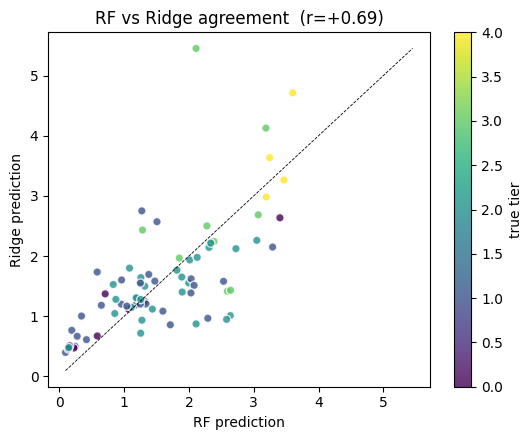

In [132]:
from scipy import stats


def report(y_pred_cont):
    """Round a continuous OOF score to the nearest valid tier index [0, K-1].
    Headline metrics live in the final comparison cell; this just materializes the
    rounded predictions the error-correlation and anomaly steps consume."""
    return np.clip(np.round(y_pred_cont), 0, len(RARITY_ORDER) - 1).astype(int)


y_round_rf = report(y_pred_rf)
y_round_ridge = report(y_pred_ridge)

pred_corr = stats.pearsonr(y_pred_rf, y_pred_ridge).statistic
print(f"RF vs Ridge prediction correlation: r = {pred_corr:+.3f}")

plt.figure(figsize=(5.5, 4.5))
plt.scatter(y_pred_rf, y_pred_ridge, c=y, cmap="viridis", alpha=0.8, edgecolor="white")
lo = min(y_pred_rf.min(), y_pred_ridge.min())
hi = max(y_pred_rf.max(), y_pred_ridge.max())
plt.plot([lo, hi], [lo, hi], color="black", linewidth=0.6, linestyle="--")
plt.xlabel("RF prediction")
plt.ylabel("Ridge prediction")
plt.title(f"RF vs Ridge agreement  (r={pred_corr:+.2f})")
plt.colorbar(label="true tier")
plt.tight_layout()
plt.show()

### A third opinion: revisiting the ordinal model

Framing 1 parked the ordinal approach on an *inconclusive* assumption check, not a real rejection — so it's earned a fair second look. We use a robust variant, **All-Threshold ordinal logistic regression** (`mord.LogisticAT`). It's essentially regularized proportional-odds OLR (one shared slope vector across rungs), but its loss penalizes *every* threshold a label violates rather than just the nearest one — which uses the full ordinal signal of each label and is sturdier against the cutpoint-level label noise we expect.

Two clarifications, since this is easy to get wrong:

- AT still **assumes proportional odds** (shared slopes) — we are *not* claiming that assumption holds. What it does *not* assume is equal tier spacing: the thresholds between tiers are learned freely. (That equal-spacing assumption actually belongs to the *regression* framing, which encodes rarity as 0–4 — not to OLR.)
- We justify using it anyway exactly as we justified Ridge: **we only use the score to rank items, not to interpret coefficients.** For a ranking task a violated assumption doesn't invalidate the model — it just makes it a candidate predictor whose worth is decided *empirically*. So we relax the assumption and let cross-validation judge: if honoring the ordinal structure natively buys anything, it'll show up in the metrics; if not, it won't make the cut.

To keep that judgment fair, AT runs through the **exact same harness** as the others: the same inverse-frequency weighting (so the thin `legendary`/`artifact` tiers aren't drowned out) and the same repeated cross-validation. We also print its run-to-run consistency — a model that swings between cross-validation repeats isn't trustworthy regardless of its average score.

In [133]:
from mord import LogisticAT

# Scale (stable thresholds) + LogisticAT. oof_predict already builds inverse-frequency
# sample_weight; route it to the LogisticAT step. AT = All-Threshold ordinal logit.
olr_factory = lambda: Pipeline([("sc", StandardScaler()), ("olr", LogisticAT(alpha=1.0))])
y_pred_olr, preds_olr_all = oof_predict(olr_factory, X, y, weight_key="olr__sample_weight")
y_round_olr = report(y_pred_olr)


# Run-to-run consistency: recompute the ordinal metrics on each repeat's OOF preds → mean ± std
def _repeat_metrics(preds_all, y_true):
    maes, qwks = [], []
    for r in range(preds_all.shape[0]):
        yr = np.clip(np.round(preds_all[r]), 0, len(RARITY_ORDER) - 1).astype(int)
        pcm = [
            mean_absolute_error(y_true[y_true == k], yr[y_true == k])
            for k in range(len(RARITY_ORDER)) if (y_true == k).any()
        ]
        maes.append(np.mean(pcm))
        qwks.append(cohen_kappa_score(y_true, yr, weights="quadratic"))
    return np.array(maes), np.array(qwks)


maes, qwks = _repeat_metrics(preds_olr_all, y)
print(
    f"OLR per-repeat consistency (5 repeats):  "
    f"macro-MAE={maes.mean():.3f}±{maes.std():.3f}   QWK={qwks.mean():.3f}±{qwks.std():.3f}"
)

OLR per-repeat consistency (5 repeats):  macro-MAE=0.630±0.066   QWK=0.597±0.041


### Final comparison: every model, scored the same way

Now the head-to-head. All four candidates plus a baseline (that always predicts the average rarity) go through the identical out-of-fold protocol. To compare them on one scale, regressors use their raw score and classifiers use their *expected tier* (`Σ kP(k)`, the probability-weighted average tier).

**The first sanity check:** every real model must beat the baseline — if it can't outperform "always guess the average," it has learned nothing.

We read four metrics together because no single one tells the whole story (see the notes after the table), and we add a **per-class signed-residual** chart. That chart is the key diagnostic: it shows the *direction* of each model's bias — whether it systematically under-rates the top tiers or over-rates the bottom — which the headline averages hide.

OOF metrics — every model must beat Baseline (classifiers scored on E[tier]):
          macro_MAE    QWK  spearman  ±1_acc
Baseline      1.200  0.000     0.208   0.835
RF-reg        0.698  0.568     0.558   0.937
Ridge         0.695  0.553     0.531   0.924
RF-clf        0.807  0.524     0.626   0.962
OLR           0.682  0.598     0.579   0.975

Per-class signed residual (pred − true;  >0 over-, <0 under-predicts):
           Baseline  RF-reg  Ridge  RF-clf   OLR
uncommon        2.0    0.87   1.00    1.28  1.05
rare            1.0    0.25   0.32    0.50  0.35
very_rare       0.0   -0.34  -0.53   -0.29 -0.45
legendary      -1.0   -0.62  -0.31   -0.86 -0.51
artifact       -2.0   -0.62  -0.35   -1.33 -0.42

Per-class mean prediction:
           Baseline  RF-reg  Ridge  RF-clf   OLR
uncommon        2.0    0.87   1.00    1.28  1.05
rare            2.0    1.25   1.32    1.50  1.35
very_rare       2.0    1.66   1.47    1.71  1.55
legendary       2.0    2.38   2.69    2.14  2.49
artifact     

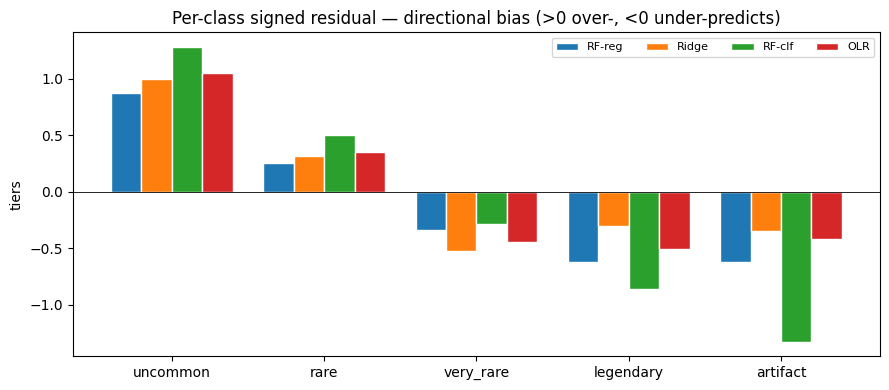

In [134]:
from sklearn.dummy import DummyRegressor

# Common currency: regressors score on raw output, classifiers on E[tier] = Σ k·P(k).
raw = lambda est, Xte: est.predict(Xte)
etier = lambda est, Xte: est.predict_proba(Xte) @ est.classes_
K = len(RARITY_ORDER)

rfclf_factory = lambda: RandomForestClassifier(
    n_estimators=500, max_depth=4, min_samples_leaf=5, random_state=0, n_jobs=-1,
)

# name -> (factory, weight_key, score_fn)
MODELS = {
    "Baseline": (lambda: DummyRegressor(strategy="mean"), "sample_weight",        raw),
    "RF-reg":   (rf_factory,                              "sample_weight",        raw),
    "Ridge":    (ridge_factory,                           "ridge__sample_weight", raw),
    "RF-clf":   (rfclf_factory,                           "sample_weight",        etier),
    "OLR":      (olr_factory,                             "olr__sample_weight",   etier),
}

scores = {nm: oof_predict(f, X, y, weight_key=wk, score=sc)[0] for nm, (f, wk, sc) in MODELS.items()}


def metrics(s):
    r = np.clip(np.round(s), 0, K - 1).astype(int)
    macro_mae = np.mean([mean_absolute_error(y[y == k], r[y == k]) for k in range(K) if (y == k).any()])
    return {
        "macro_MAE": macro_mae,
        "QWK":       cohen_kappa_score(y, r, weights="quadratic"),
        "spearman":  0.0 if np.std(s) == 0 else stats.spearmanr(y, s).statistic,  # const baseline → undefined
        "±1_acc":    np.mean(np.abs(y - r) <= 1),
    }


summary = pd.DataFrame({nm: metrics(s) for nm, s in scores.items()}).T
print("OOF metrics — every model must beat Baseline (classifiers scored on E[tier]):")
print(summary.round(3).to_string())

# Per-class directional bias
signed = pd.DataFrame({nm: [(scores[nm][y == k] - y[y == k]).mean() for k in range(K)] for nm in MODELS}, index=RARITY_ORDER)
mean_pred = pd.DataFrame({nm: [scores[nm][y == k].mean() for k in range(K)] for nm in MODELS}, index=RARITY_ORDER)
print("\nPer-class signed residual (pred − true;  >0 over-, <0 under-predicts):")
print(signed.round(2).to_string())
print("\nPer-class mean prediction:")
print(mean_pred.round(2).to_string())

ax = signed.drop(columns="Baseline").plot(kind="bar", figsize=(9, 4), edgecolor="white", width=0.8)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Per-class signed residual — directional bias (>0 over-, <0 under-predicts)")
ax.set_ylabel("tiers")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

**How to read the metrics** — each covers a blind spot of the others:

- **macro-MAE** and **QWK** are *distance-aware*: they care how far off a prediction is, and QWK is averaged so the small `legendary`/`artifact` tiers aren't ignored. These are our primary scores.
- **Spearman** ignores the raw numbers and asks only whether the items are *ranked* in the right order — useful since we ultimately rank items, not classify them.
- **±1-accuracy** (within-one-tier hits) is easy to read but *flatters the majority classes* — with `rare` + `very_rare` making up most items, a model can score well just by parking everything in the middle. So we read it last, never alone.
- **Per-class signed residual / mean prediction** expose *direction*: a model can have a fine average while quietly under-rating every `artifact`. This is what catches tail bias.

Two caveats on the numbers: the probability models (RF-clf, OLR) are scored on expected tier, an average that naturally **pulls predictions toward the middle**; and because the tails are tiny, edge-tier estimates are noisy for *every* model.

### What we keep, and why

Three models clearly beat the baseline and carry real signal: **RF, Ridge, and OLR**. The classifier lags because, as expected, it ignores the ordering. Among the three survivors a clear pattern emerges:

- **RF** is strongest at the low end but **compresses the top tiers** — it rarely predicts `artifact`.
- **Ridge** and **OLR** are the mirror image: they reach (and even overshoot) the top, but are softer at the bottom.

That makes RF and Ridge naturally **complementary** — one covers the other's weak end. The mistake-correlation table settles the third model: **OLR errs on almost the same items as Ridge** (r ≈ 0.77), while RF errs *independently*. So OLR adds little that Ridge isn't already contributing.